# Prepare Canobie Falcon data

The Geosoft XYZ data format file is commonly used in geophysics to transmit geophysical survey data in a text-readable form.

This tutorial demonstrates the preparation of XYZ airborne gravity gradiometer data, from the Canobie Falcon survey, for QC.

We need all the data in HDF5 geoWhizz format because all the QC functions expect that format. (More on the geoWhizz format elsewhere in the __pe*ga*susQC__ documentation.)

___

First, import the required modules, and set the path to the XYZ files.

In [1]:
from pathlib import Path

import pegasusQC as qc

In [2]:
data_root = r'./CanobieData/'

canobieXYZ_file = Path(data_root + r'Canobie.xyz')

plan_root = data_root
canobieXYZ_plan = Path(plan_root + r'CanobiePlan.xyz')

___

**The Survey Plan**

In this example, the plan data file only has the (x,y) locations of the start and end of each line and we have no planned heights. This means we will not be able to check the aircraft altitudes against the drape plan but nothing else will be affected.

In [3]:
canobieHDF_plan = qc.xyzToHDF(Path(canobieXYZ_plan), projectName='Canobie')
block_name = 'Canobie Survey Plan'
qc.updateProject(canobieHDF_plan, acquirer='Xcalibur Multiphysics', blockID=block_name)

Accessing XYZ data in CanobieData/CanobiePlan.xyz.
First few records are:
/EASTING  NORTHING  FLAG

LINE      1


  Found 1 header records
  Found 78 lines
  Found 3 fields

Channel precisions (number of decimal places): [0 0 0]
Creating:  CanobieData/CanobiePlan.hdf5
Setting BlockID = Canobie Survey Plan for CanobiePlan.hdf5.
Setting Acquirer = Xcalibur Multiphysics for CanobiePlan.hdf5.


In [4]:
qc.updateCoordFrame(canobieHDF_plan,
                    x='EASTING', 
                    y='NORTHING', 
                    geoDatum='WGS84', 
                    projection='UTM', 
                    utmz='54')

Changed CoordFrame attribute(s) for CanobiePlan.hdf5.


In [5]:
qc.updateLineAttributes(canobieHDF_plan, line_type='Xcal_can')

NO ACTION TAKEN ON LINE_TYPE - no plan file provided.

Setting Line attributes for CanobiePlan.hdf5 according to the Xcal_can scheme.


In [6]:
qc.updateChannelAttributes(canobieHDF_plan, 'EASTING', units='m')
qc.updateChannelAttributes(canobieHDF_plan, 'NORTHING', units='m')

Changed channel attribute(s) for EASTING in CanobiePlan.hdf5.
Changed channel attribute(s) for NORTHING in CanobiePlan.hdf5.


In [7]:
qc.reportWhizz(canobieHDF_plan)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Canobie Survey Plan
    ProjectName: Canobie

Coordinates
    GeoDatum: WGS84
    Projection: UTM
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
78 lines: total distance flown [km] = 4,985.7

78 lines:
 ['1.000', '100010.000', '100020.000', '100030.000', '100040.000', '100050.000', '100060.000', '100070.000', '100080.000', '100090.000', '100100.000', '100110.000', '100120.000', '100130.000', '100140.000', '100150.000', '100160.000', '100170.000', '100180.000', '100190.000', '100200.000', '100210.000', '100220.000', '100230.000', '100240.000', '100250.000', '100260.000', '100270.000', '100280.000', '100290.000', '100300.000', '100310.000', '100320.000', '100330.000', '100340.000', '100350.000', '100360.000', '100370.000', '100380.000', '100390.000', '100400.000', '100410.000', '100420.000', '100430.000', '100440.000', '100450.000', '100460.000', '100470.000', '100480.000', '100490.000', '100500.000', '10051

___

**The Measured Survey Data**

In [8]:
canobieHDF_file = qc.xyzToHDF(canobieXYZ_file, projectName='Canobie')

Accessing XYZ data in CanobieData/Canobie.xyz.
First few records are:
/ANE_TC_2p67 AUV_TC_2p67    Bearing BNE_TC_2p67 BUV_TC_2p67  CLEARANCE       Date        DTM    EASTING     FIDUCIAL FLIGHT gD_Fourier_2p67 GDD_Fourier_2p67 GNE_Fourier_2p67 GUV_Fourier_2p67       HDOP     HEIGHT     JOB_ID         LATITUDE       LINE        LONGITUDE   Noise_NE   Noise_UV   NORTHING NumSats       PDOP       T_DD       T_NE       T_UV  Time_1980   Time_Day TURBULENCE       VDOP

Line  100010


  Found 1 header records
  Found 6 lines
  Found 33 fields

Channel precisions (number of decimal places): [3 3 1 3 3 3 0 1 3 3 0 2 2 2 2 3 3 0 8 3 8 2 2 3 0 3 2 2 2 3 3 3 3]
Creating:  CanobieData/Canobie.hdf5


In [9]:
block_name = 'Prelim Canobie Data'
qc.updateProject(canobieHDF_file, acquirer='Xcalibur Multiphysics', blockID=block_name)
qc.updateCoordFrame(canobieHDF_file, 
                    lat='LATITUDE', 
                    lon='LONGITUDE', 
                    x='EASTING', 
                    y='NORTHING', 
                    time='Time_1980', 
                    alt='HEIGHT', 
                    geoDatum='WGS84', 
                    htDatum='WGS84', 
                    projection='UTM', 
                    utmz='54')

Setting BlockID = Prelim Canobie Data for Canobie.hdf5.
Setting Acquirer = Xcalibur Multiphysics for Canobie.hdf5.
Changed CoordFrame attribute(s) for Canobie.hdf5.


In [10]:
qc.updateLineAttributes(canobieHDF_file, planfiles=canobieHDF_plan,
                        line_type='Xcal_can', flight_chan='FLIGHT', date_chan='Date')

Setting Line attributes for CanobieData/Canobie.hdf5 to include flight numbers from FLIGHT.
Setting Line attributes for CanobieData/Canobie.hdf5 to include date values from Date.

Setting Line attributes for Canobie.hdf5 according to the Xcal_can scheme.
Verifying planned line numbers against provided plan file(s).


In [11]:
qc.updateChannelAttributes(canobieHDF_file, 'ANE_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'AUV_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'Bearing', units='degrees')
qc.updateChannelAttributes(canobieHDF_file, 'BNE_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'BUV_TC_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'CLEARANCE', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'Date')
qc.updateChannelAttributes(canobieHDF_file, 'DTM', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'EASTING', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'FIDUCIAL')
qc.updateChannelAttributes(canobieHDF_file, 'FLIGHT')
qc.updateChannelAttributes(canobieHDF_file, 'gD_Fourier_2p67', units='µm/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'GDD_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'GNE_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'GUV_Fourier_2p67', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'HDOP')
qc.updateChannelAttributes(canobieHDF_file, 'HEIGHT', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'JOB_ID')
qc.updateChannelAttributes(canobieHDF_file, 'LATITUDE', units='degree')
qc.updateChannelAttributes(canobieHDF_file, 'LINE')
qc.updateChannelAttributes(canobieHDF_file, 'LONGITUDE', units='degree')
qc.updateChannelAttributes(canobieHDF_file, 'Noise_NE', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'Noise_UV', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'NORTHING', units='metre')
qc.updateChannelAttributes(canobieHDF_file, 'NumSats')
qc.updateChannelAttributes(canobieHDF_file, 'PDOP')
qc.updateChannelAttributes(canobieHDF_file, 'T_DD', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'T_NE', units='eotvos')
qc.updateChannelAttributes(canobieHDF_file, 'T_UV', units='µm/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'Time_1980', units='seconds')
qc.updateChannelAttributes(canobieHDF_file, 'Time_Day', units='seconds')
qc.updateChannelAttributes(canobieHDF_file, 'TURBULENCE', units='m/s/s')
qc.updateChannelAttributes(canobieHDF_file, 'VDOP')

Changed channel attribute(s) for ANE_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for AUV_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for Bearing in Canobie.hdf5.
Changed channel attribute(s) for BNE_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for BUV_TC_2p67 in Canobie.hdf5.
Changed channel attribute(s) for CLEARANCE in Canobie.hdf5.
No changes made.
Changed channel attribute(s) for DTM in Canobie.hdf5.
Changed channel attribute(s) for EASTING in Canobie.hdf5.
No changes made.
No changes made.
Changed channel attribute(s) for gD_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GDD_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GNE_Fourier_2p67 in Canobie.hdf5.
Changed channel attribute(s) for GUV_Fourier_2p67 in Canobie.hdf5.
No changes made.
Changed channel attribute(s) for HEIGHT in Canobie.hdf5.
No changes made.
Changed channel attribute(s) for LATITUDE in Canobie.hdf5.
No changes made.
Changed channel attribute(s) for LONG

In [12]:
qc.reportWhizz(canobieHDF_file)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Coordinates
    AltitudeChannel: HEIGHT
    GeoDatum: WGS84
    HeightDatum: WGS84
    LatitudeChannel: LATITUDE
    LongitudeChannel: LONGITUDE
    Projection: UTM
    TimeChannel: Time_1980
    UTMZone: 54
    XChannel: EASTING
    YChannel: NORTHING
6 lines: total distance flown [km] = 360.0

6 lines:
 ['100010.000', '100020.000', '100030.000', '100040.000', '100050.000', '100060.000']

33 channels:
 ['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67', 'Bearing', 'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL', 'FLIGHT', 'GDD_Fourier_2p67', 'GNE_Fourier_2p67', 'GUV_Fourier_2p67', 'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE', 'LINE', 'LONGITUDE', 'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP', 'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP', 'gD_Fourier_2p67']


In [13]:
qc.reportFlights(canobieHDF_file, flightChannel='FLIGHT', detailed=True)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

2 flights including 6 lines.

Flights
    2
      L100010.000 L100020.000 
    3
      L100030.000 L100040.000 L100050.000 L100060.000 



In [14]:
qc.reportSampling(canobieHDF_file)

Whizz Version 1.0
    Acquirer: Xcalibur Multiphysics
    BlockID: Prelim Canobie Data
    ProjectName: Canobie

Sample time and distance statistics
  Min   = 0.125 s, 6.8 m
  Max   = 0.126 s, 7.9 m
  Mean  = 0.125 s, 7.4 m
  Stdev = 3.33e-05 s, 0.2 m


Sample times should be constant. Here we have one at $0.126\,s$ which ought to be checked. Sample distances vary with aircraft ground speed.

___

**Make a survey flight-line map**

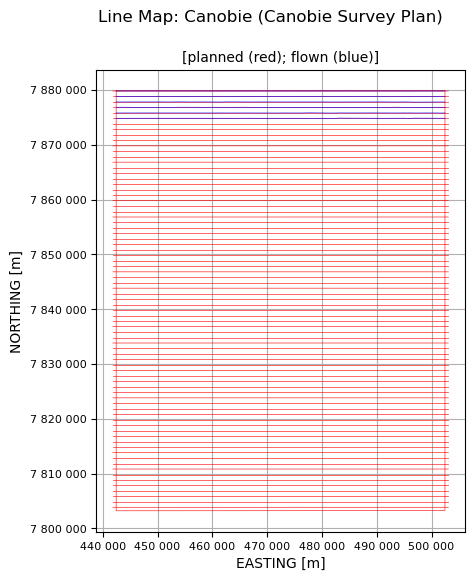

In [15]:
qc.linesMap([canobieHDF_file], whizzPlanFile=canobieHDF_plan)